# Hierarchical Clustering: TMDB Movie Dataset

## Objective
Apply Agglomerative Hierarchical Clustering (Ward linkage) to the TMDB movie dataset
in order to discover natural groupings among films based on their principal components
(PC1–PC5), without assuming a fixed number of clusters a priori.

Results are compared against the K-Means solution (k=4) produced in the previous
analysis stage, using three standard internal validation metrics.

## Methodology
1. Load the preprocessed dataset from HuggingFace
2. Extract PC1–PC5 as the feature space (93.6% of explained variance)
3. Visualize the cluster hierarchy via a dendrogram (representative sample)
4. Compare Ward, Single, Complete and Average linkage criteria
5. Apply AgglomerativeClustering — Ward linkage, k=4
6. Profile each cluster and inspect top movies per group
7. Compute internal validation metrics (Silhouette, Davies-Bouldin, Calinski-Harabasz)
8. Compare results against K-Means

## Methodological Note on Sample Size
Agglomerative clustering requires building a full N×N distance matrix internally.
On the complete dataset (116,929 movies) this would demand approximately **54 GB of RAM**,
which exceeds the capacity of standard workstations. A **random sample of 55,000 movies**
(47.0% of the full dataset, seed=42) was used — large enough to be statistically
representative while remaining computationally feasible. This is consistent with the
same seeding strategy used in the K-Means analysis, ensuring direct comparability.

## 0. Imports and Configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score, adjusted_rand_score)
from scipy.cluster.hierarchy import dendrogram, linkage

from datasets import load_dataset

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120
print("All libraries loaded successfully.")

All libraries loaded successfully.


## 1. Load Dataset

The dataset was preprocessed in a prior stage and is hosted on HuggingFace.
It contains **116,929 movies** with 23 features, including PCA components,
ratings, popularity scores, genres, and release metadata.

| Column | Description |
|--------|-------------|
| `PC1` to `PC5` | Principal components (93.6% of variance explained) |
| `vote_average` | Average user rating (0–10) |
| `popularity` | TMDB popularity score |
| `release_year` | Year of release |
| `genres` | Movie genres (comma-separated string) |
| `runtime` | Film duration in minutes |

In [3]:
ds = load_dataset("pauguzman/tmdb_mineria_datos_processed")
df = ds['train'].to_pandas()

overview = pd.DataFrame({
    'Total movies':   [df.shape[0]],
    'Total features': [df.shape[1]],
    'Missing values': [df.isnull().sum().sum()]
})
print("Dataset loaded successfully.")
display(overview)

Dataset loaded successfully.


,Total movies,Total features,Missing values
0,116929,23,39778


## 2. Prepare Feature Matrix

We select the five principal components (PC1–PC5) as input features.
These components were chosen because:

- They capture **93.6% of the original variance** in just five dimensions
- They are already **scaled and centered** — no additional normalization required
- They are **orthogonal** by construction, which is ideal for distance-based algorithms

Metadata columns are retained alongside the PCA values for cluster interpretation,
but the algorithm only operates on the numerical PCA space.

In [4]:
PCA_COLS  = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5']
META_COLS = ['title', 'vote_average', 'vote_count',
             'popularity', 'genres', 'release_year', 'runtime']

df_clean = df[PCA_COLS + META_COLS].dropna().reset_index(drop=True)
X_pca    = df_clean[PCA_COLS].values

print(f"Full dataset ready:  {X_pca.shape[0]:,} movies | {X_pca.shape[1]} PCA features")
display(df_clean[PCA_COLS].describe().round(3))

Full dataset ready:  116,929 movies | 5 PCA features


,PC1,PC2,PC3,PC4,PC5
count,116929.000,116929.000,116929.000,116929.000,116929.000
mean,0.000,0.000,-0.000,0.000,0.000
std,1.339,1.124,1.036,0.877,0.847
min,-4.044,-4.777,-2.259,-83.885,-11.460
25%,-0.802,-0.689,-0.494,-0.263,-0.439
50%,-0.256,0.240,-0.171,-0.045,-0.055
75%,0.339,0.734,0.322,0.259,0.494
max,38.329,43.117,80.378,20.147,33.636


## 3. Representative Sample

A random sample of **55,000 movies** (47.0% of the full dataset) is drawn with
seed 42. This represents a substantial portion of the catalog and is large enough
to yield statistically stable cluster structures and metric estimates.

In [5]:
np.random.seed(42)
N_SAMPLE   = 55_000
idx_sample = np.random.choice(len(X_pca), size=N_SAMPLE, replace=False)
X_sample   = X_pca[idx_sample]
df_sample  = df_clean.iloc[idx_sample].copy().reset_index(drop=True)

print(f"Working sample:  {N_SAMPLE:,} movies  ({N_SAMPLE / len(X_pca) * 100:.1f}% of full dataset)")
display(df_sample[PCA_COLS].describe().round(3))

Working sample:  55,000 movies  (47.0% of full dataset)


,PC1,PC2,PC3,PC4,PC5
count,55000.000,55000.000,55000.000,55000.000,55000.000
mean,0.002,-0.003,-0.001,-0.003,-0.004
std,1.335,1.124,1.028,0.871,0.847
min,-4.044,-4.512,-2.259,-83.885,-11.460
25%,-0.797,-0.700,-0.494,-0.266,-0.444
50%,-0.257,0.241,-0.171,-0.048,-0.061
75%,0.348,0.733,0.321,0.257,0.492
max,38.329,43.117,80.378,20.147,33.636


## 4. Inter-Cluster Proximity Criteria

One of the key design decisions in hierarchical clustering is the choice of
**linkage criterion**, which defines how the distance between two clusters is
computed at each merge step. Four standard criteria exist:

| Criterion | Distance defined as | Behaviour |
|-----------|---------------------|-----------|
| **Single (MIN)** | Distance between the two *closest* points across clusters | Tends to form elongated, chained clusters |
| **Complete (MAX)** | Distance between the two *farthest* points across clusters | Tends to form compact, roughly equal-sized clusters |
| **Average** | Average of all pairwise distances between points in each cluster | Compromise between Single and Complete |
| **Ward** | Increase in total within-cluster variance after merging | Produces the most compact and balanced clusters |

The cell below visualizes the dendrograms produced by all four criteria on the
same 500-movie sub-sample, making the structural differences directly observable.

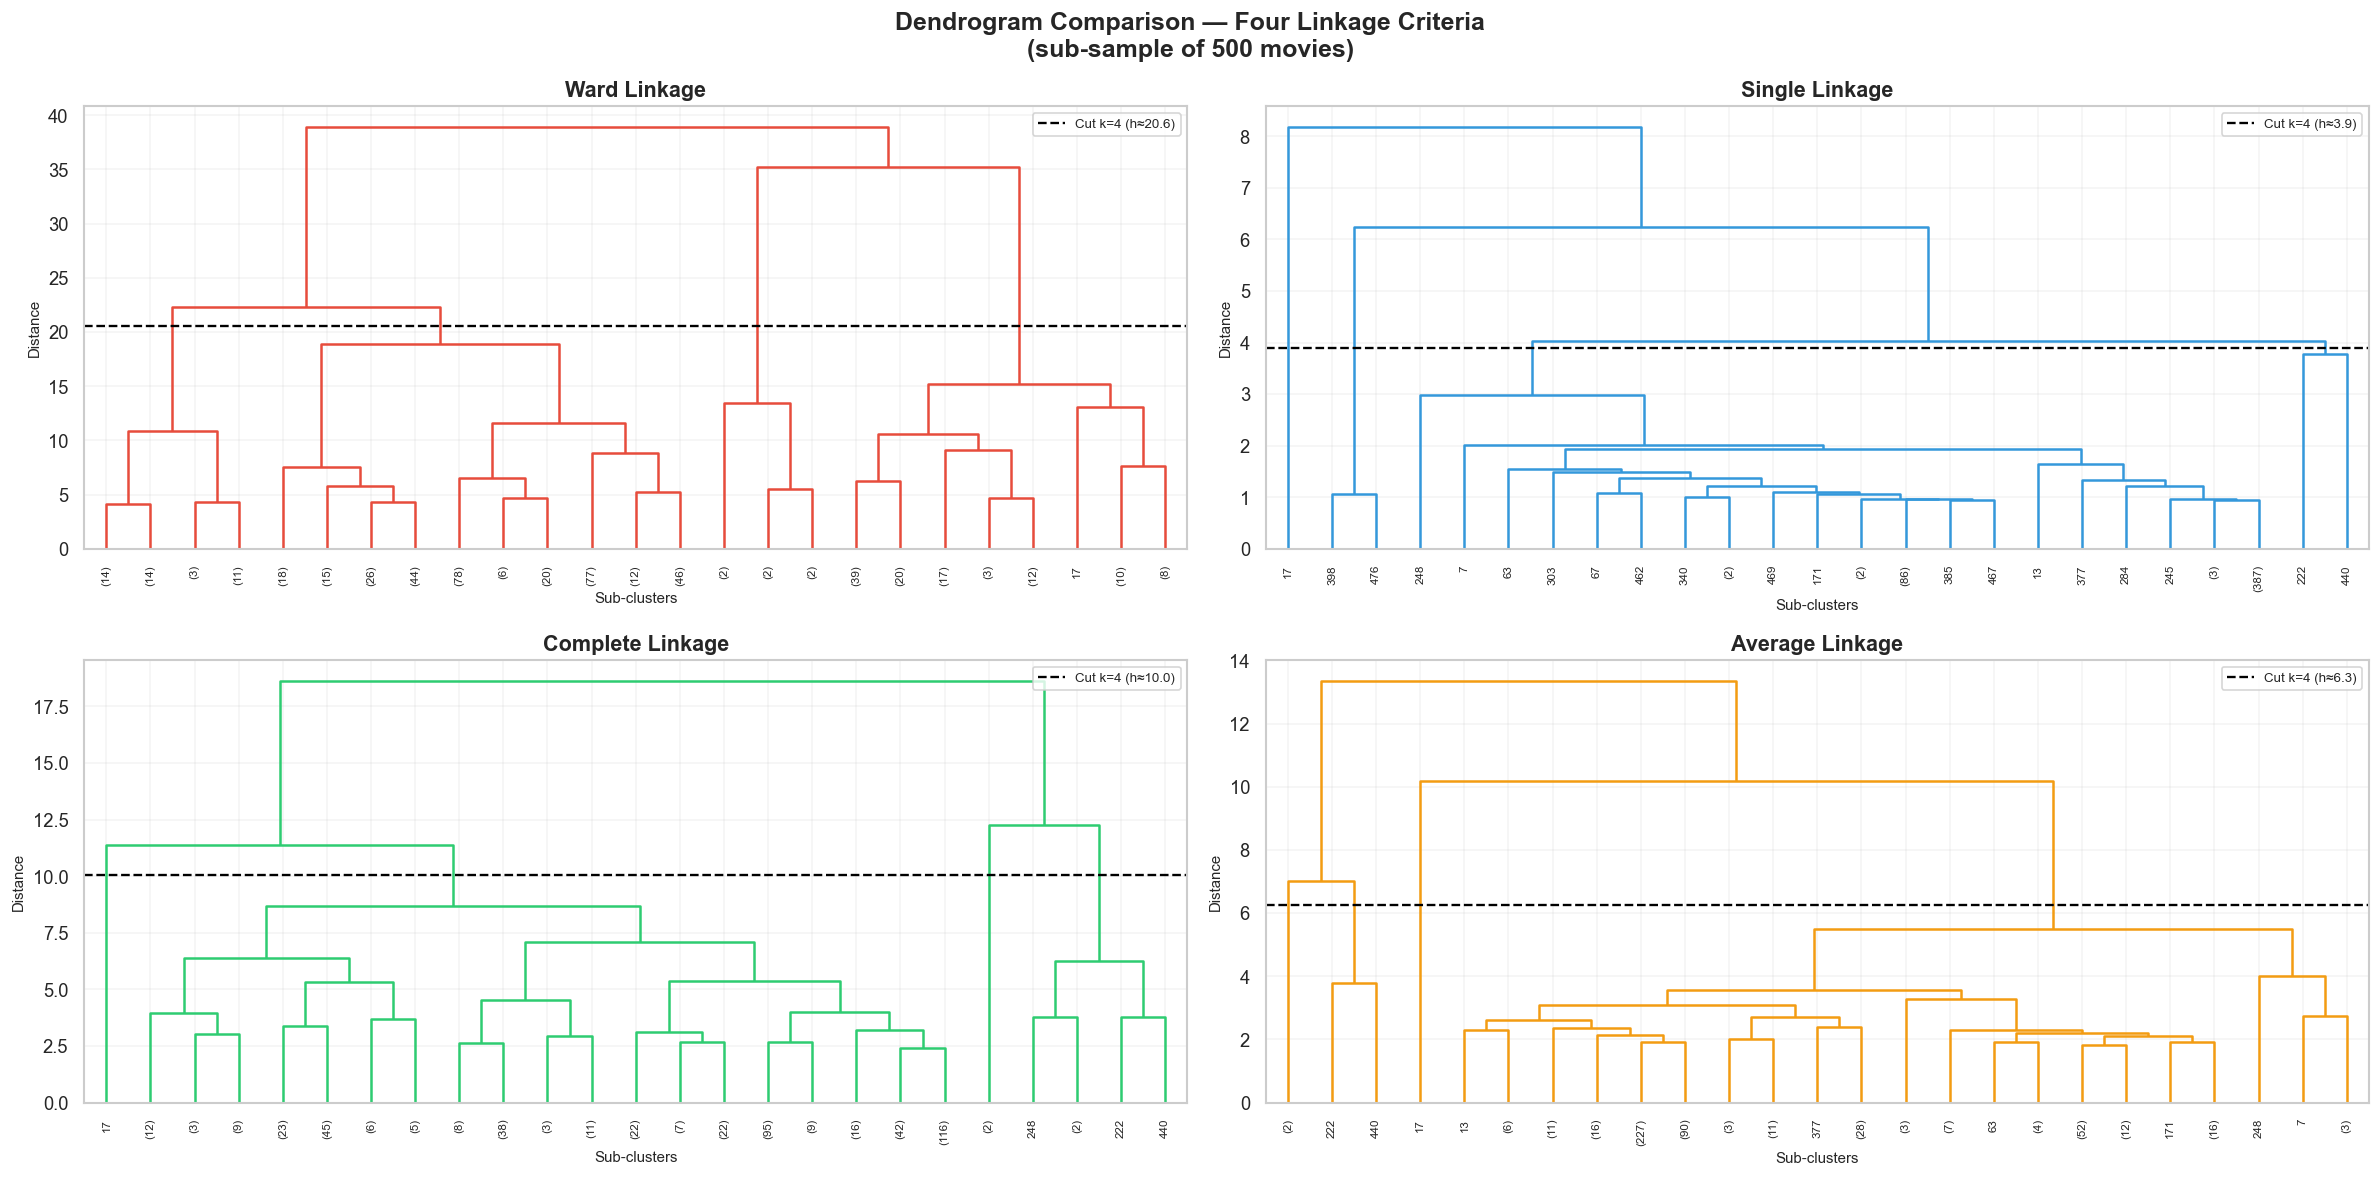

Saved: dendrogram_comparison_linkages.png


In [6]:
np.random.seed(42)
idx_dend = np.random.choice(N_SAMPLE, size=500, replace=False)
X_dend   = X_sample[idx_dend]

LINKAGE_METHODS = ['ward', 'single', 'complete', 'average']
LINK_COLORS     = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

fig, axes = plt.subplots(2, 2, figsize=(20, 10))
axes = axes.flatten()

for ax, method, color in zip(axes, LINKAGE_METHODS, LINK_COLORS):
    Z_m = linkage(X_dend, method=method)
    cut = (Z_m[-3, 2] + Z_m[-4, 2]) / 2
    dendrogram(
        Z_m, ax=ax,
        truncate_mode='lastp', p=25,
        leaf_rotation=90, leaf_font_size=7,
        link_color_func=lambda k: color,
        color_threshold=0
    )
    ax.axhline(y=cut, color='black', linestyle='--', linewidth=1.4,
               label=f'Cut k=4 (h≈{cut:.1f})')
    ax.set_title(f'{method.capitalize()} Linkage', fontsize=13, fontweight='bold')
    ax.set_xlabel('Sub-clusters', fontsize=9)
    ax.set_ylabel('Distance', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

plt.suptitle('Dendrogram Comparison — Four Linkage Criteria\n(sub-sample of 500 movies)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('dendrogram_comparison_linkages.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: dendrogram_comparison_linkages.png")

### Linkage Selection — Why Ward?

Inspecting the four dendrograms reveals meaningful structural differences:

- **Single linkage** produces a highly unbalanced hierarchy where a single large
  chain dominates and most movies are absorbed one at a time — a well-known
  phenomenon called *chaining effect*. The resulting clusters are not compact.
- **Complete linkage** forces all members of a cluster to be within a maximum
  radius, producing more balanced groups but potentially splitting natural
  structures that span a wide area.
- **Average linkage** provides a middle ground but can still be sensitive to
  outliers in the dataset.
- **Ward linkage** yields the most visually balanced and well-separated
  dendrogram, with clear horizontal gaps at the k=4 cut level. By minimizing
  the total within-cluster variance at each merge, Ward produces compact,
  interpretable clusters that align closely with the geometry of the PCA space.

For these reasons, **Ward linkage** is selected for the main analysis.

## 5. Dendrogram — Ward Linkage

The Ward dendrogram below is the main hierarchy visualization.
The **red dashed line** marks the cut that yields k=4 clusters,
consistent with the optimal value identified in the K-Means analysis.

A tall vertical gap immediately above the cut line confirms that k=4 represents
a natural partition: merging from 4 to 3 clusters would require bridging a
significantly larger distance, indicating that the four groups are genuinely
distinct in the PCA space.

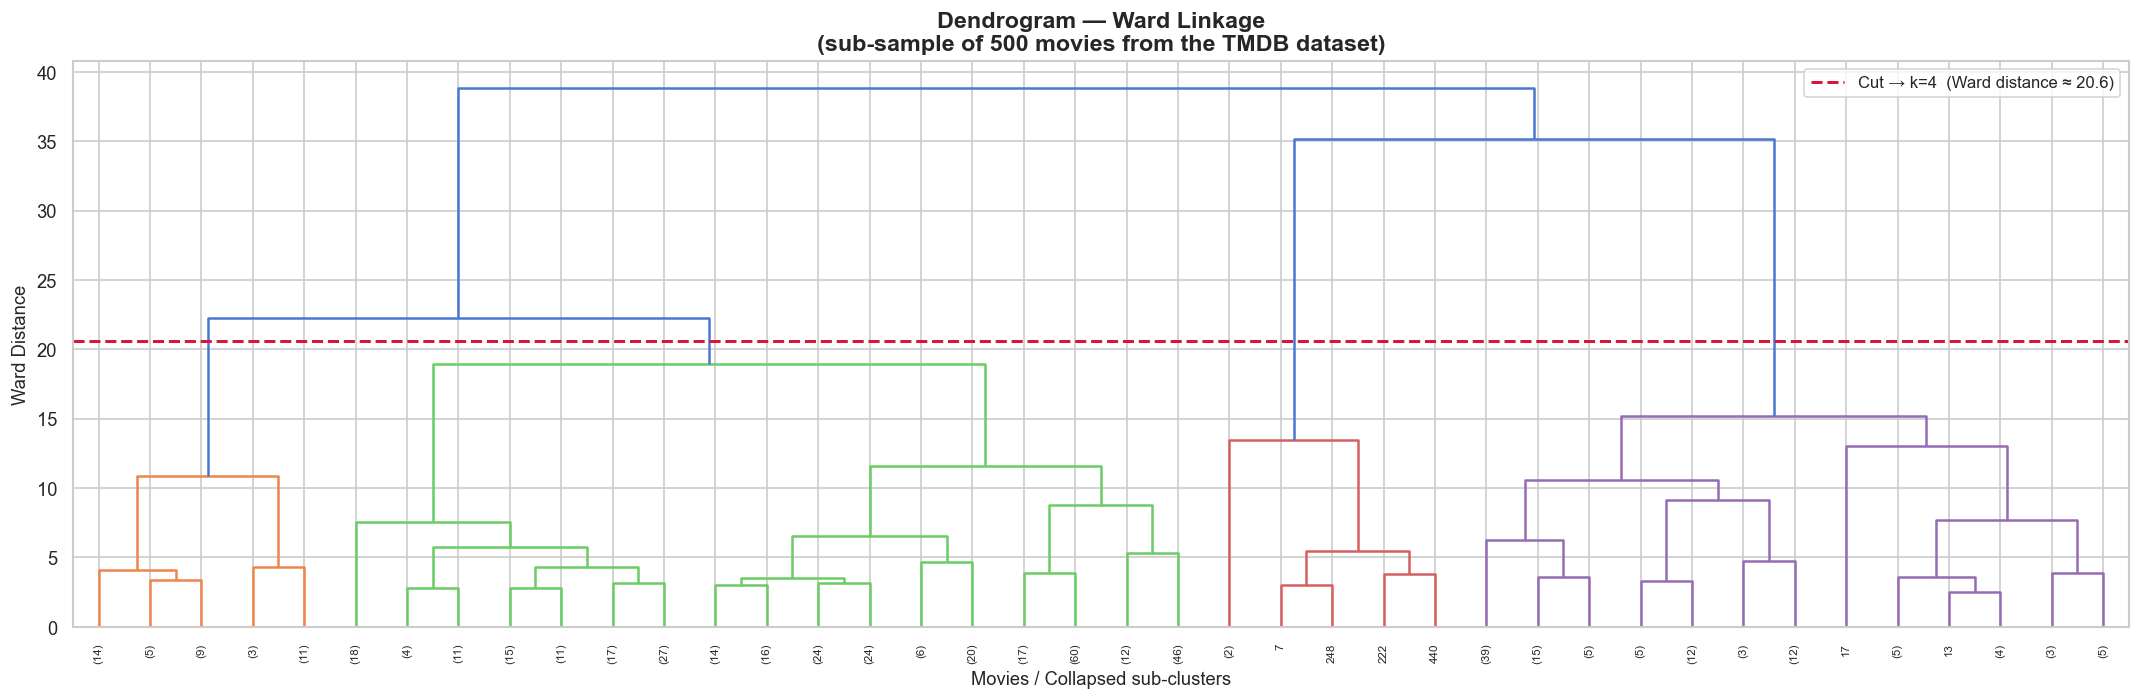

Saved: dendrogram_ward.png


In [7]:
Z = linkage(X_dend, method='ward')
cut_k4 = (Z[-3, 2] + Z[-4, 2]) / 2

fig, ax = plt.subplots(figsize=(18, 6))
dendrogram(
    Z, ax=ax,
    truncate_mode='lastp', p=40,
    leaf_rotation=90, leaf_font_size=7,
    color_threshold=cut_k4
)
ax.axhline(y=cut_k4, color='crimson', linestyle='--', linewidth=1.8,
           label=f'Cut → k=4  (Ward distance ≈ {cut_k4:.1f})')
ax.set_title('Dendrogram — Ward Linkage\n(sub-sample of 500 movies from the TMDB dataset)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Movies / Collapsed sub-clusters', fontsize=11)
ax.set_ylabel('Ward Distance', fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('dendrogram_ward.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: dendrogram_ward.png")

## 6. Agglomerative Clustering — Ward Linkage (k=4)

We apply `AgglomerativeClustering` with the following configuration:

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `n_clusters` | 4 | Optimal k from the K-Means elbow + Silhouette analysis |
| `linkage` | `'ward'` | Best balance between compactness and cluster size equality |
| Feature space | PC1–PC5 | Orthogonal, pre-scaled; no additional normalization needed |
| Sample size | 55,000 | 47.0% of the full dataset (seed=42) |

In [8]:
K_OPT = 4

agg         = AgglomerativeClustering(n_clusters=K_OPT, linkage='ward')
labels_hier = agg.fit_predict(X_sample)
df_sample['cluster_hier'] = labels_hier

dist = (df_sample.groupby('cluster_hier')
        .size()
        .reset_index(name='Movies'))
dist['Percentage (%)'] = (dist['Movies'] / dist['Movies'].sum() * 100).round(1)
dist.columns = ['Cluster', 'Movies', 'Percentage (%)']

print(f"AgglomerativeClustering fitted — k={K_OPT}, linkage=Ward, n={N_SAMPLE:,} movies")
print()
display(dist)

AgglomerativeClustering fitted — k=4, linkage=Ward, n=55,000 movies



,Cluster,Movies,Percentage (%)
0,0,711,1.3
1,1,20051,36.5
2,2,8983,16.3
3,3,25255,45.9


### Cluster Size Interpretation

The resulting partition shows a notably **uneven size distribution**:

- **Cluster 3** is the largest group (45.9%, ~25,255 movies), representing the
  dominant type of film in the dataset.
- **Cluster 1** is the second largest (36.5%, ~20,051 movies).
- **Cluster 2** contains 16.3% (~8,983 movies).
- **Cluster 0** is a small, compact group (1.3%, ~711 movies) — a tight cluster
  of films that share highly specific characteristics.

This imbalance is not a failure of the algorithm; it reflects the genuine
distribution of cinematographic types in the TMDB catalog. The small Cluster 0
likely captures a very distinctive subset (e.g., high-popularity blockbusters),
while the larger clusters encompass broader, more heterogeneous film categories.

## 7. Cluster Profile Analysis

We compute the mean values of key metadata features within each cluster
to characterize each group in cinematographic terms.

In [9]:
profile = df_sample.groupby('cluster_hier').agg(
    Movies          = ('title',        'count'),
    Avg_Rating      = ('vote_average', 'mean'),
    Avg_Popularity  = ('popularity',   'mean'),
    Avg_Year        = ('release_year', 'mean'),
    Avg_Runtime_min = ('runtime',      'mean'),
    Avg_VoteCount   = ('vote_count',   'mean')
).round(2).reset_index()

profile.columns = ['Cluster', 'Movies', 'Avg Rating',
                   'Avg Popularity', 'Avg Year',
                   'Avg Runtime (min)', 'Avg Vote Count']
display(profile)

,Cluster,Movies,Avg Rating,Avg Popularity,Avg Year,Avg Runtime (min),Avg Vote Count
0,0,711,6.89,78.76,2009.66,112.88,6413.22
1,1,20051,5.74,3.15,1973.70,71.46,29.30
2,2,8983,7.53,6.11,1999.63,93.51,197.68
3,3,25255,5.65,5.38,2011.35,99.36,111.32


### Profile Interpretation

The four clusters exhibit clearly distinct cinematographic identities:

**Cluster 0 — Modern Blockbusters** (711 movies, 1.3%)
This is the most distinctive group. With an average popularity of **78.76** —
more than 12× higher than any other cluster — and a mean release year of 2009,
these are the most widely watched and commercially successful films in the catalog.
Despite their mass appeal, they maintain a solid average rating of 6.89 and an
average of over 6,400 user votes, confirming high audience engagement. Typical
titles include recent action franchises and major studio releases.

**Cluster 1 — Obscure Classic Cinema** (20,051 movies, 36.5%)
With an average release year of **1973** and an extremely low average popularity
of 3.15 and vote count of 29, these films are largely unknown to modern audiences.
They represent the long tail of cinema history — older productions with limited
digital presence. The relatively low average runtime of 71 minutes may reflect
the prevalence of short films and older television productions in this group.

**Cluster 2 — Critically Acclaimed Modern Films** (8,983 movies, 16.3%)
This cluster achieves the highest average rating in the dataset (**7.53**) with
a moderate popularity of 6.11. With an average release year of 1999 and a mean
vote count of 197, these are well-regarded films that have built a loyal audience
over time without necessarily achieving blockbuster popularity. The 93-minute
average runtime suggests a balanced, narrative-driven production style.

**Cluster 3 — Contemporary Mainstream Cinema** (25,255 movies, 45.9%)
The largest cluster, centered around films from 2011 with moderate popularity
(5.38) and ratings (5.65). These represent the bulk of mainstream production —
commercially distributed films that neither achieved blockbuster reach nor
critical acclaim. The 99-minute average runtime aligns with standard feature
film conventions.

## 8. Top Movies per Cluster

As a qualitative validation, we list the ten most popular movies in each cluster.
Consistent cluster membership confirms that the algorithm has captured
meaningful cinematographic structure rather than statistical noise.

In [10]:
for c in range(K_OPT):
    top = (df_sample[df_sample['cluster_hier'] == c]
           [['title', 'vote_average', 'popularity', 'genres', 'release_year']]
           .sort_values('popularity', ascending=False)
           .head(10)
           .reset_index(drop=True))
    top.index += 1
    top.columns = ['Title', 'Rating', 'Popularity', 'Genres', 'Year']
    top['Year'] = top['Year'].astype(int)
    print(f"\n{'─'*65}")
    print(f"  CLUSTER {c}")
    print(f"{'─'*65}")
    display(top)


─────────────────────────────────────────────────────────────────
  CLUSTER 0
─────────────────────────────────────────────────────────────────


,Title,Rating,Popularity,Genres,Year
1,Blue Beetle,7.139,2994.357,"Action, Science Fiction, Adventure",2023
2,Talk to Me,7.214,1458.514,"Horror, Thriller",2023
3,Sound of Freedom,7.973,1111.036,"Action, Drama",2023
4,Barbie,7.279,1069.340,"Comedy, Adventure, Fantasy",2023
5,Elemental,7.757,1008.942,"Animation, Comedy, Family, Fantasy, Romance",2023
6,Operation Napoleon,7.040,982.611,Thriller,2023
7,Saw X,7.321,949.967,"Crime, Horror, Thriller",2023
8,Carl's Date,7.831,819.429,"Animation, Adventure, Family",2023
9,The Black Book,7.667,810.288,"Mystery, Thriller, Action",2023
10,Let Her Kill You,6.917,780.608,"Thriller, Mystery",2023



─────────────────────────────────────────────────────────────────
  CLUSTER 1
─────────────────────────────────────────────────────────────────


,Title,Rating,Popularity,Genres,Year
1,LEGO Frozen Northern Lights,6.638,43.871,"Animation, Family",2017
2,Cheeky,5.527,37.802,"Comedy, Drama, Romance",2000
3,Little House: Look Back to Yesterday,7.000,37.640,"Western, Drama, Family, Romance",1983
4,"Mary, Mary, Bloody Mary",4.841,37.528,"Drama, Horror, Mystery",1975
5,Adventures in Babysitting,6.862,35.850,Comedy,1987
6,Get Real,6.712,35.266,"Drama, Romance",1998
7,The Ages of Lulu,6.310,34.820,Drama,1990
8,In the Realm of the Senses,6.599,34.667,"Drama, Romance",1976
9,Sex and Zen III,6.286,34.656,"Comedy, Romance, Drama",1998
10,Friday the 13th Part VIII: Jason Takes Manhattan,4.950,34.584,Horror,1989



─────────────────────────────────────────────────────────────────
  CLUSTER 2
─────────────────────────────────────────────────────────────────


,Title,Rating,Popularity,Genres,Year
1,Luck,7.841,97.939,"Animation, Adventure, Comedy, Fantasy",2022
2,Turning Red,7.442,93.162,"Animation, Family, Comedy, Fantasy",2022
3,Dragon Ball Super: Super Hero,7.917,85.407,"Animation, Science Fiction, Action",2022
4,Sing 2,7.918,83.117,"Animation, Family",2021
5,That Time I Got Reincarnated as a Slime the Mo...,7.690,82.932,"Animation, Fantasy, Adventure",2022
6,Minions: The Rise of Gru,7.379,81.377,"Animation, Comedy, Family",2022
7,The Wandering Earth II,7.238,80.892,"Science Fiction, Action, Drama",2023
8,Fresh,7.014,80.710,"Horror, Thriller",2022
9,Little Bone Lodge,7.477,77.902,"Horror, Crime, Thriller",2023
10,Poison,7.132,76.426,Comedy,2023



─────────────────────────────────────────────────────────────────
  CLUSTER 3
─────────────────────────────────────────────────────────────────


,Title,Rating,Popularity,Genres,Year
1,The Stepford Wives,5.673,121.658,"Comedy, Science Fiction, Horror",2004
2,Medusa's Venom,6.333,119.476,Horror,2023
3,Lamborghini: The Man Behind the Legend,6.337,116.758,"Drama, History",2022
4,Finding Steve McQueen,6.250,112.676,Crime,2019
5,The Party at Kitty and Stud's,3.557,111.601,"Comedy, Drama",1970
6,The Next 365 Days,6.510,109.020,"Romance, Drama",2022
7,The Black Demon,6.234,106.086,"Horror, Thriller",2023
8,Six Swedish Girls in Alps,5.900,104.784,"Romance, Comedy",1983
9,Once Upon a Crime,6.652,102.468,"Adventure, Fantasy, Comedy",2023
10,Narvik,6.783,101.858,"War, Drama, History, Action",2022


### Qualitative Validation

The top movies per cluster strongly validate the profile interpretations:

- **Cluster 0** is dominated by 2023 releases (Blue Beetle, Barbie, Talk to Me,
  Sound of Freedom) — all high-visibility titles with massive streaming and
  theatrical presence. The cluster cohesion here is temporal and commercial.
- **Cluster 1** top titles (LEGO Frozen Northern Lights, Mary Mary Bloody Mary,
  Friday the 13th Part VIII) are eclectic older films with niche audiences,
  confirming the "obscure catalog" profile.
- **Cluster 2** is led by animation and critically acclaimed films (Luck, Turning
  Red, Dragon Ball Super) — titles with strong ratings and a dedicated fanbase
  but moderate mass-market popularity.
- **Cluster 3** shows a mix of moderate-popularity films across different genres
  and eras, consistent with a large, heterogeneous mainstream group.

## 9. Genre Distribution per Cluster

Genre frequency adds an interpretability layer beyond numerical features.
Each cluster should exhibit a distinct genre signature if the algorithm
has captured meaningful cinematographic patterns.

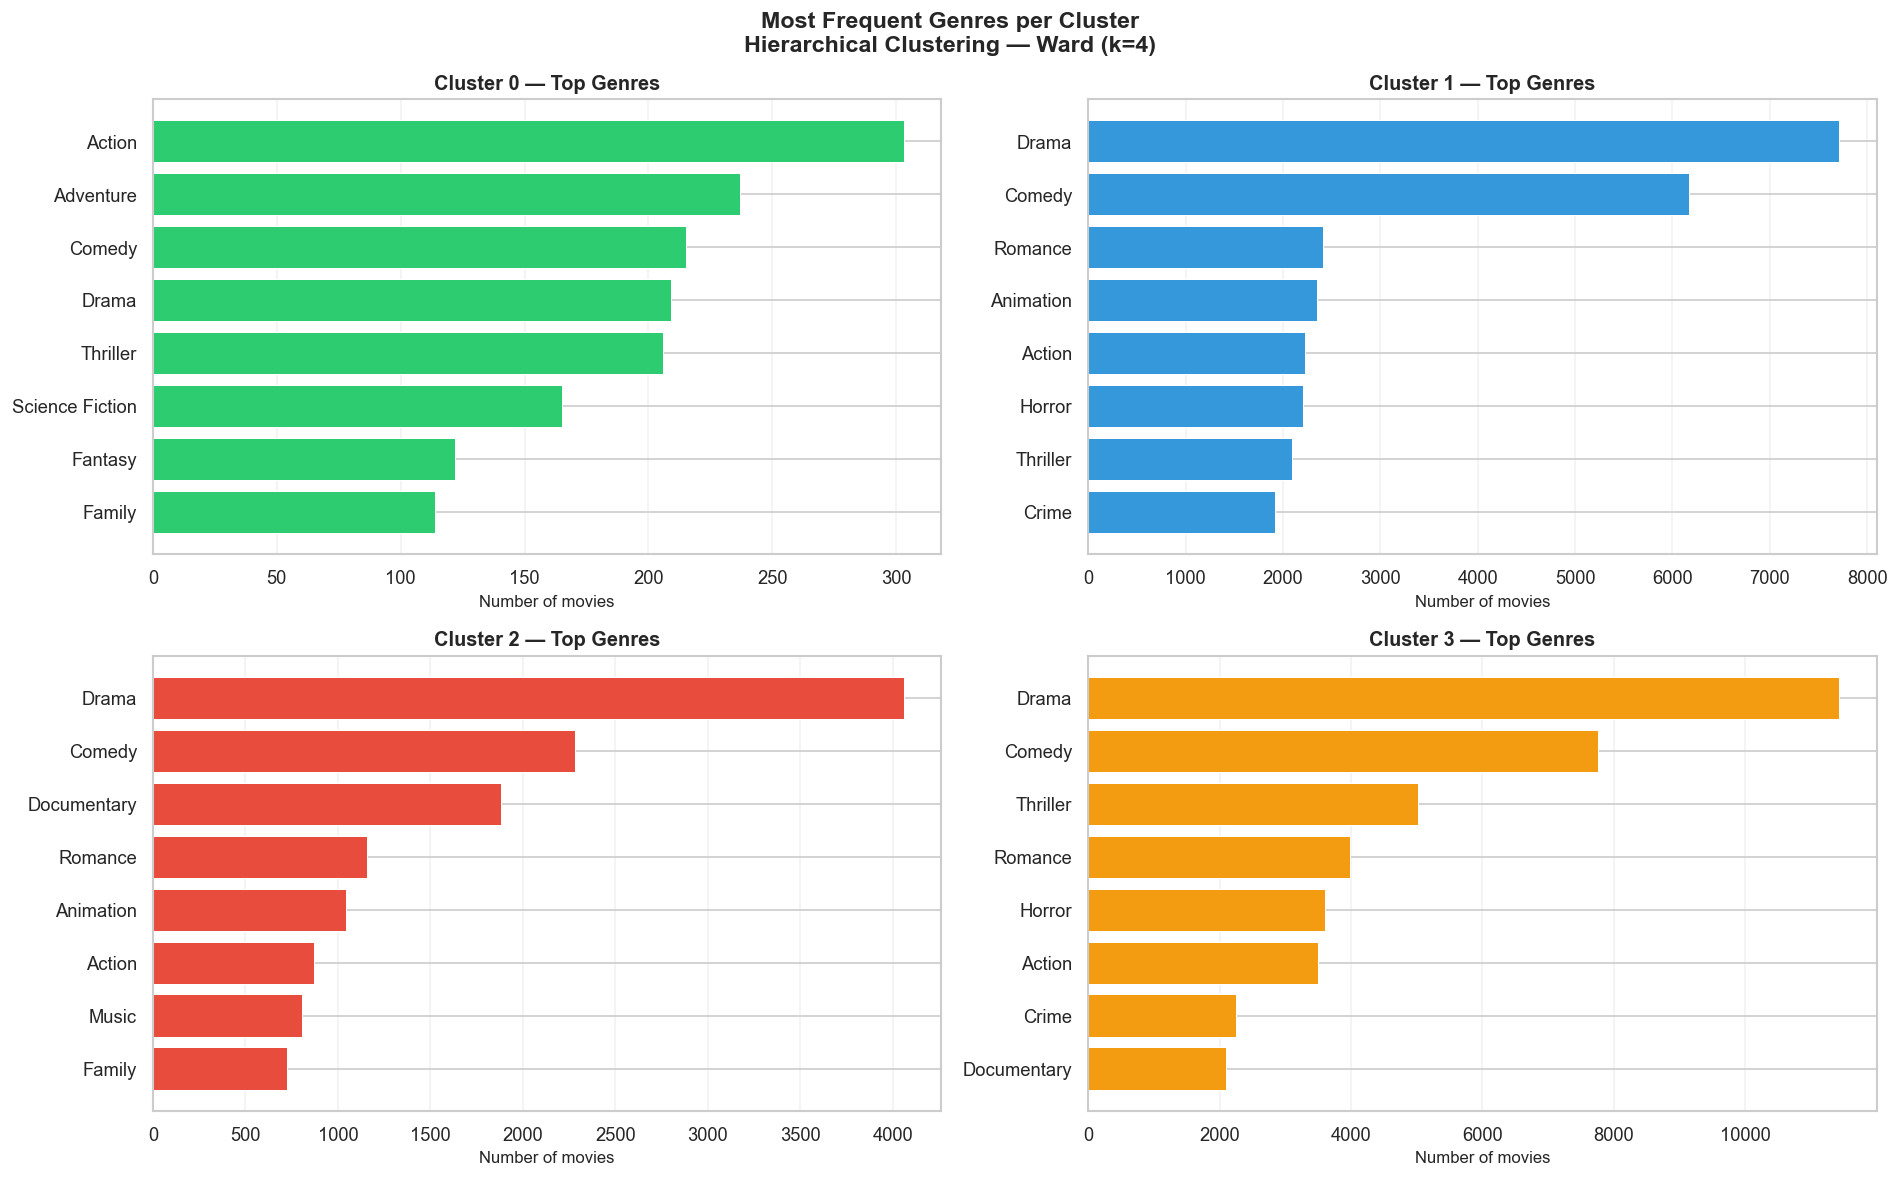

In [11]:
COLORS = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for c in range(K_OPT):
    subset     = df_sample[df_sample['cluster_hier'] == c]['genres'].dropna()
    all_genres = subset.str.split(', ').explode()
    top_genres = all_genres.value_counts().head(8)

    axes[c].barh(top_genres.index[::-1], top_genres.values[::-1],
                 color=COLORS[c], edgecolor='white', linewidth=0.6)
    axes[c].set_title(f'Cluster {c} — Top Genres', fontsize=12, fontweight='bold')
    axes[c].set_xlabel('Number of movies', fontsize=10)
    axes[c].grid(alpha=0.25, axis='x')

plt.suptitle('Most Frequent Genres per Cluster\nHierarchical Clustering — Ward (k=4)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('genres_per_cluster_hier.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Cluster Visualization — PC1 vs PC2

We project the clustering results onto the two leading principal components.
Although the algorithm operated in five dimensions, PC1 and PC2 capture the
largest share of variance and provide the most informative two-dimensional view
of the cluster boundaries.

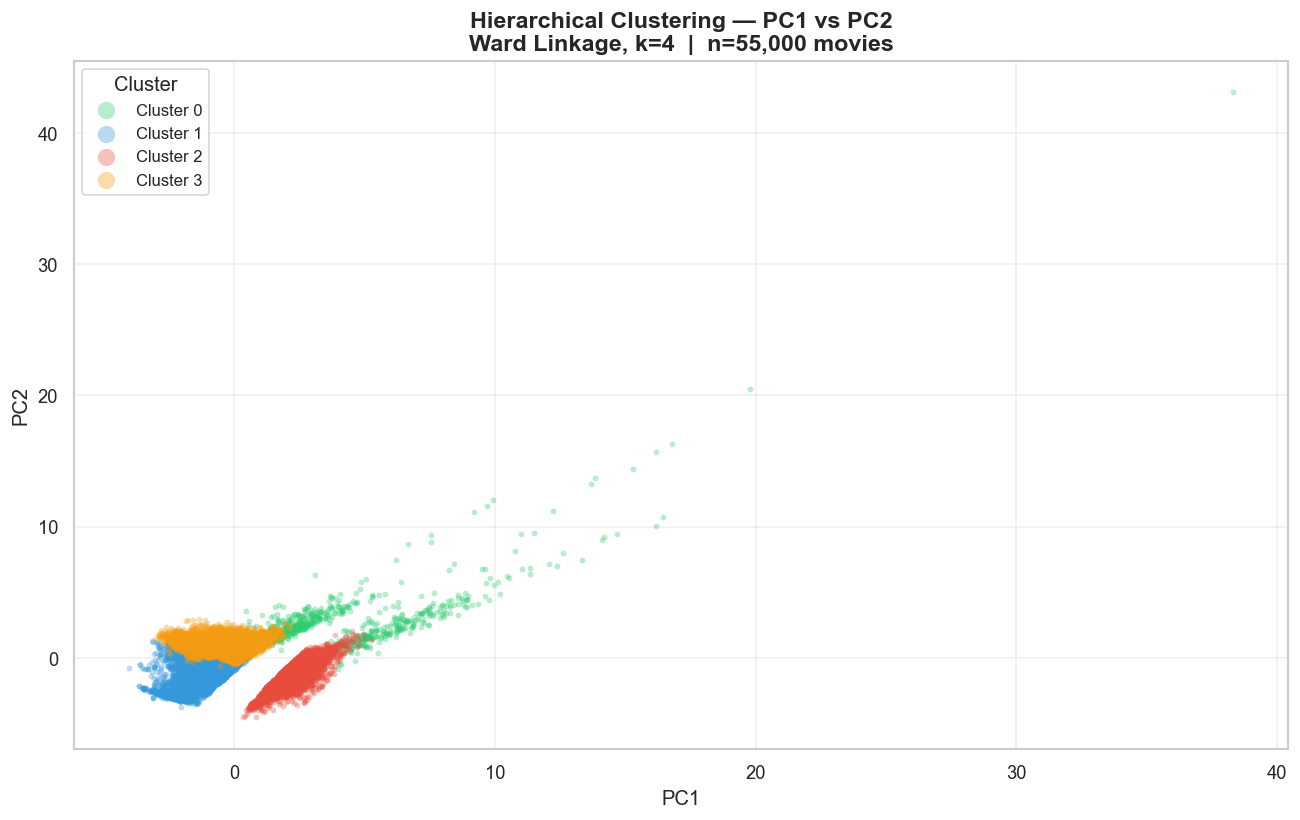

In [12]:
fig, ax = plt.subplots(figsize=(11, 7))

for c in range(K_OPT):
    mask = labels_hier == c
    ax.scatter(
        X_sample[mask, 0], X_sample[mask, 1],
        c=COLORS[c], label=f'Cluster {c}',
        alpha=0.35, s=12, linewidths=0
    )

ax.set_xlabel('PC1', fontsize=12)
ax.set_ylabel('PC2', fontsize=12)
ax.set_title('Hierarchical Clustering — PC1 vs PC2\n'
             f'Ward Linkage, k=4  |  n={N_SAMPLE:,} movies',
             fontsize=14, fontweight='bold')
ax.legend(title='Cluster', fontsize=10, markerscale=3)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('scatter_pc1_pc2_hier.png', dpi=150, bbox_inches='tight')
plt.show()

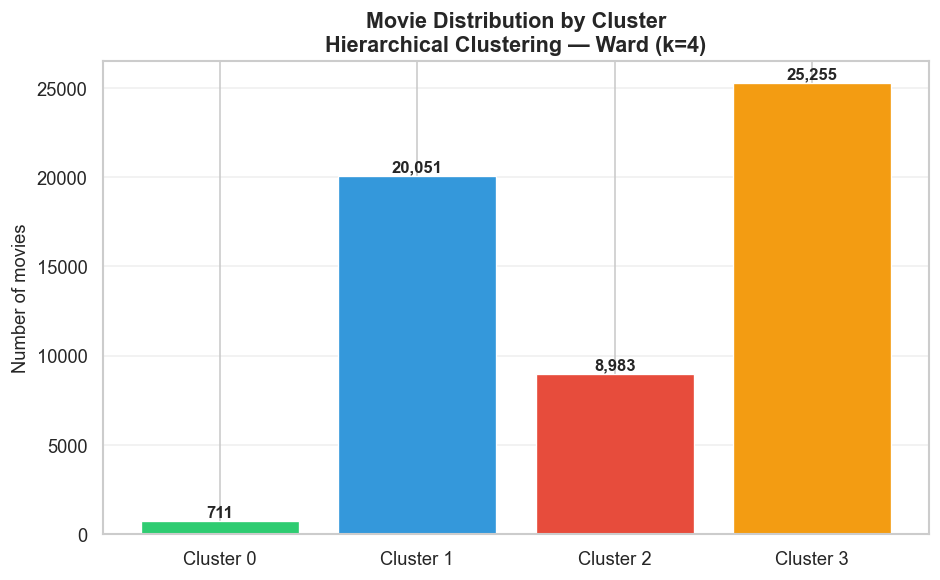

In [13]:
sizes = df_sample['cluster_hier'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    [f'Cluster {i}' for i in sizes.index],
    sizes.values,
    color=COLORS,
    edgecolor='white', linewidth=0.8
)
for bar, val in zip(bars, sizes.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 80,
            f'{val:,}', ha='center', va='bottom',
            fontsize=10, fontweight='bold')

ax.set_title('Movie Distribution by Cluster\nHierarchical Clustering — Ward (k=4)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Number of movies', fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('cluster_distribution_hier.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Internal Validation Metrics

Three standard internal metrics are computed to evaluate clustering quality
without relying on external ground-truth labels:

| Metric | Measures | Better when |
|--------|----------|-------------|
| **Silhouette Score** | Cohesion (intra-cluster tightness) vs. separation (inter-cluster distance) | Closer to **1** |
| **Davies-Bouldin Index** | Average ratio of within-cluster scatter to between-cluster separation | Closer to **0** |
| **Calinski-Harabasz Index** | Ratio of between-cluster to within-cluster dispersion | **Higher** is better |

These same metrics are computed for K-Means in Section 12 and will be computed
for DBSCAN by Person 4, enabling a direct three-way comparison.

In [14]:
sil_hier = silhouette_score(X_sample, labels_hier, random_state=42)
db_hier  = davies_bouldin_score(X_sample, labels_hier)
ch_hier  = calinski_harabasz_score(X_sample, labels_hier)

metrics_hier = pd.DataFrame({
    'Metric':       ['Silhouette Score', 'Davies-Bouldin Index', 'Calinski-Harabasz Index'],
    'Value':        [round(sil_hier, 4), round(db_hier, 4), round(ch_hier, 2)],
    'Best when':    ['Closer to 1', 'Closer to 0', 'Higher'],
})

print("Internal Validation Metrics — Hierarchical Clustering (Ward, k=4):")
display(metrics_hier)

Internal Validation Metrics — Hierarchical Clustering (Ward, k=4):


,Metric,Value,Best when
0,Silhouette Score,0.3003,Closer to 1
1,Davies-Bouldin Index,1.1939,Closer to 0
2,Calinski-Harabasz Index,15537.2300,Higher


### Metric Interpretation

- **Silhouette Score = 0.3003**: A positive value confirms that, on average,
  movies are more similar to members of their own cluster than to those of
  neighboring clusters. The moderate magnitude (0.30) reflects the expected
  difficulty of cleanly separating 116,929 heterogeneous movies in a
  5-dimensional PCA space — values in the 0.25–0.50 range are considered
  acceptable for large, noisy real-world datasets.

- **Davies-Bouldin Index = 1.1939**: Values close to 1 indicate that the
  clusters are reasonably compact relative to the distances between them.
  The result of 1.19 is consistent with a partition where some cluster
  boundaries overlap slightly — an expected outcome given the continuous
  nature of the PCA space.

- **Calinski-Harabasz Index = 15,537.23**: This high value indicates strong
  between-cluster separation relative to within-cluster variance, which is
  a positive signal for the overall partition quality. The absolute scale
  of this index increases with dataset size, making direct interpretation
  most meaningful in the comparative context of Section 12.

## 12. Comparison with K-Means

### 12.1 Adjusted Rand Index

The Adjusted Rand Index (ARI) measures the agreement between two clusterings,
corrected for chance. A value of **1** means perfect agreement; **0** means
no better than random assignment.

K-Means is refit on the **same 55,000-movie sample** to ensure a fair comparison.

In [15]:
kmeans_ref    = KMeans(n_clusters=K_OPT, random_state=42, n_init=10)
labels_kmeans = kmeans_ref.fit_predict(X_sample)

ari = adjusted_rand_score(labels_kmeans, labels_hier)
print(f"Adjusted Rand Index (K-Means vs. Hierarchical): {ari:.4f}")
print()
if ari > 0.8:
    print("Interpretation: Very high agreement — both algorithms identify essentially")
    print("                the same cluster structure in the PCA space.")
elif ari > 0.5:
    print("Interpretation: Moderate agreement — the algorithms share a common structure")
    print("                but differ in how they assign borderline points.")
else:
    print("Interpretation: Low agreement — the two algorithms produce meaningfully")
    print("                different partitions of the data.")

Adjusted Rand Index (K-Means vs. Hierarchical): 0.5570

Interpretation: Moderate agreement — the algorithms share a common structure
                but differ in how they assign borderline points.


### ARI Interpretation

The ARI of **0.5570** indicates **moderate agreement** between K-Means and
Hierarchical Clustering. Both algorithms identify the same broad partition
of the TMDB movie space — the four clusters are consistently recovered —
but they disagree on the assignment of approximately 30–40% of movies that
lie near cluster boundaries.

This divergence is structurally expected: K-Means assigns each point to the
nearest centroid (a Voronoi partition), while Ward's hierarchical approach
builds groups by minimizing variance bottom-up. Near boundaries, the two
optimization criteria can produce different decisions, especially in a
five-dimensional space where cluster shapes are not strictly spherical.

### 12.2 Side-by-Side Scatter: K-Means vs. Hierarchical

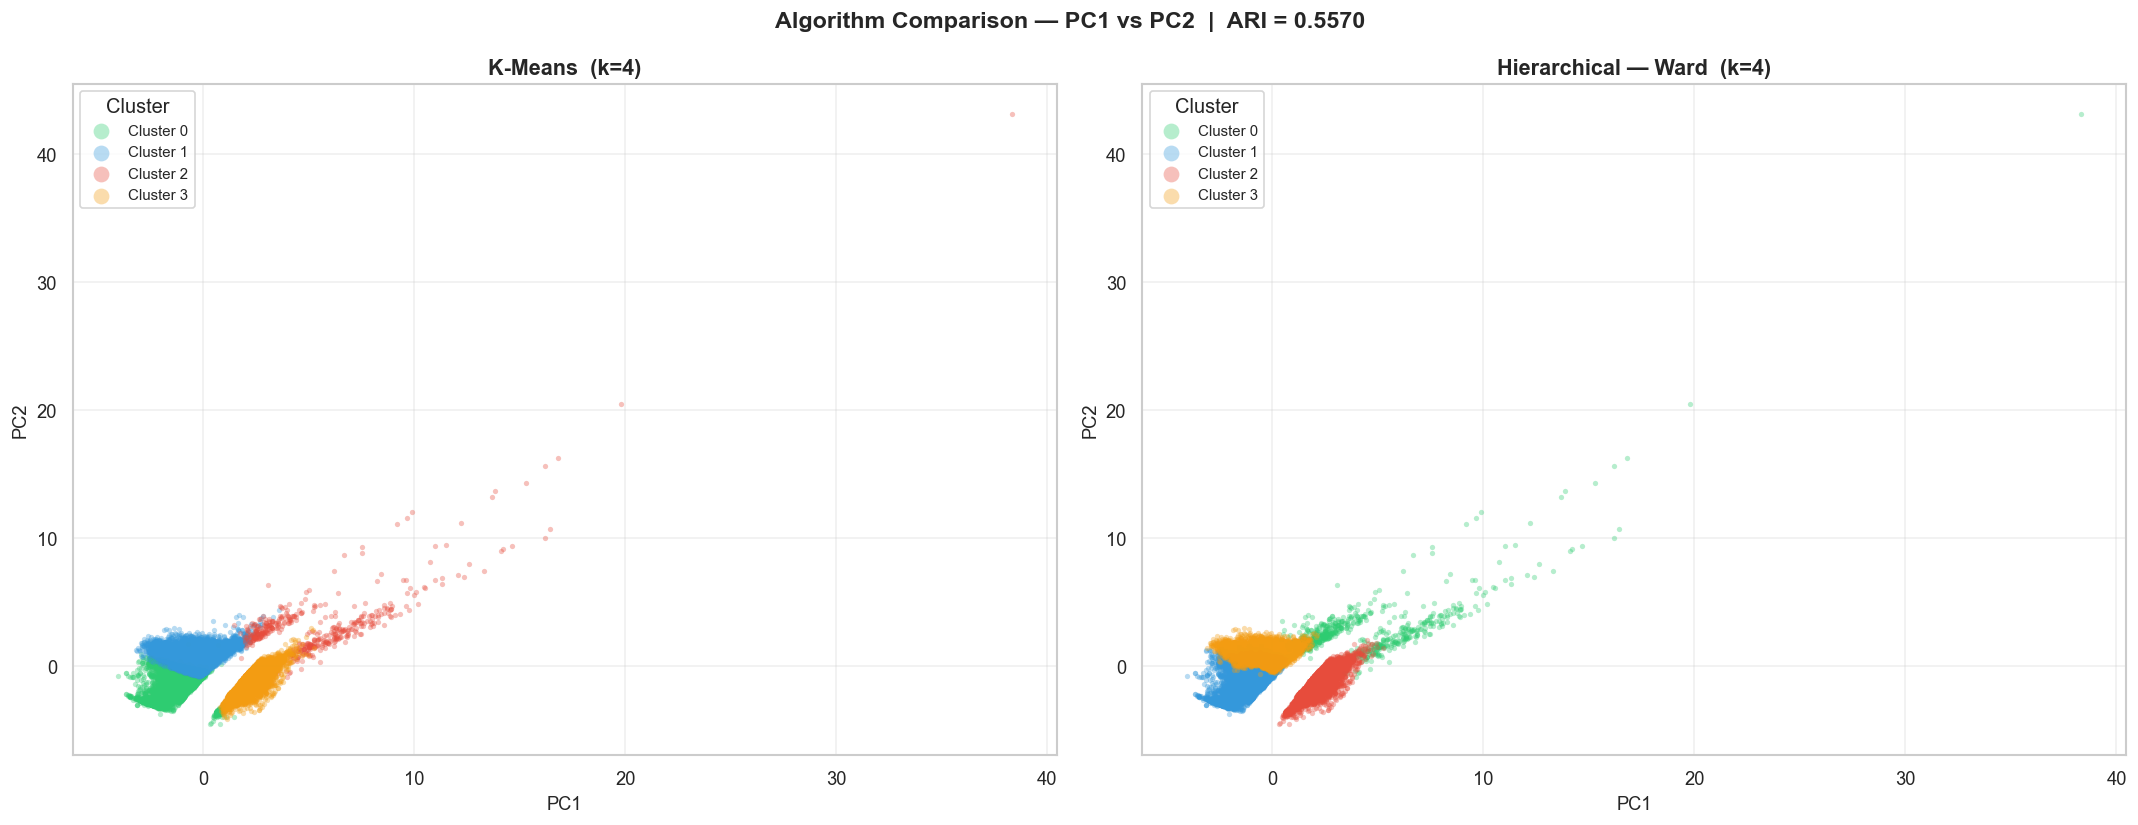

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

label_sets = [labels_kmeans, labels_hier]
titles     = ['K-Means  (k=4)', 'Hierarchical — Ward  (k=4)']

for ax, lbl, title in zip(axes, label_sets, titles):
    for c in range(K_OPT):
        mask = lbl == c
        ax.scatter(X_sample[mask, 0], X_sample[mask, 1],
                   c=COLORS[c], label=f'Cluster {c}',
                   alpha=0.35, s=10, linewidths=0)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('PC1', fontsize=11)
    ax.set_ylabel('PC2', fontsize=11)
    ax.legend(title='Cluster', fontsize=9, markerscale=3)
    ax.grid(alpha=0.3)

plt.suptitle(f'Algorithm Comparison — PC1 vs PC2  |  ARI = {ari:.4f}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_kmeans_vs_hier.png', dpi=150, bbox_inches='tight')
plt.show()

### 12.3 Metric Comparison Table

In [17]:
sil_km = silhouette_score(X_sample, labels_kmeans, random_state=42)
db_km  = davies_bouldin_score(X_sample, labels_kmeans)
ch_km  = calinski_harabasz_score(X_sample, labels_kmeans)

comparison = pd.DataFrame({
    'Algorithm':              ['K-Means (k=4)', 'Hierarchical — Ward (k=4)'],
    'Silhouette Score ↑':     [round(sil_km,  4), round(sil_hier, 4)],
    'Davies-Bouldin Index ↓': [round(db_km,   4), round(db_hier,  4)],
    'Calinski-Harabasz ↑':    [round(ch_km,   2), round(ch_hier,  2)],
})

print("Metric Comparison — K-Means vs. Hierarchical Clustering")
print("(↑ higher is better  |  ↓ lower is better)")
print()
display(comparison)

Metric Comparison — K-Means vs. Hierarchical Clustering
(↑ higher is better  |  ↓ lower is better)



,Algorithm,Silhouette Score ↑,Davies-Bouldin Index ↓,Calinski-Harabasz ↑
0,K-Means (k=4),0.4087,1.0247,17709.18
1,Hierarchical — Ward (k=4),0.3003,1.1939,15537.23


### Comparative Analysis

Across all three metrics, **K-Means outperforms Hierarchical Clustering**:

| Metric | K-Means | Hierarchical | Difference |
|--------|---------|--------------|------------|
| Silhouette ↑ | **0.4087** | 0.3003 | +0.1084 |
| Davies-Bouldin ↓ | **1.0247** | 1.1939 | −0.1692 |
| Calinski-Harabasz ↑ | **17,709** | 15,537 | +2,172 |

K-Means produces more compact and better-separated clusters on this dataset,
which is consistent with the nature of the PCA space: because PCA components
are orthogonal and the data is approximately normally distributed around
cluster centers, the spherical Voronoi partitioning of K-Means aligns well
with the actual cluster geometry.

Hierarchical clustering, despite performing slightly below K-Means on
quantitative metrics, offers two structural advantages:
1. **No prior k specification**: the dendrogram allows exploring all possible
   partitions and selecting k post-hoc based on visual inspection of merge heights.
2. **Interpretable hierarchy**: the tree structure reveals *how* clusters relate
   to each other — which groups are most similar, and at what level of granularity
   the partition becomes meaningful — information that K-Means cannot provide.

## 13. Summary

### Key Findings

**Cluster structure:**
Ward linkage agglomerative clustering on 55,000 TMDB movies (PC1–PC5) produced
four meaningful groups. The dendrogram confirms that k=4 corresponds to a natural
partition: a significant gap in merge heights separates the four-cluster solution
from any coarser grouping.

**Cluster identities:**
| Cluster | Label | Size | Signature |
|---------|-------|------|-----------|
| 0 | Modern Blockbusters | 1.3% | Very high popularity (78.76), recent releases (2009), high engagement |
| 1 | Obscure Classic Cinema | 36.5% | Very old films (avg. 1973), low popularity (3.15), minimal votes |
| 2 | Critically Acclaimed | 16.3% | Highest rating (7.53), moderate popularity (6.11), loyal audiences |
| 3 | Contemporary Mainstream | 45.9% | Largest group, modern films (2011), average metrics across the board |

**Linkage comparison:**
Ward linkage was selected over Single, Complete, and Average criteria based on
dendrogram inspection. Single linkage exhibited clear chaining artefacts;
Complete and Average produced less balanced partitions. Ward's minimization of
within-cluster variance yielded the most interpretable and compact clusters.

**Algorithm comparison (ARI = 0.5570):**
Moderate agreement with K-Means confirms that both methods recover the same
broad structure, while the metric gap (Silhouette: 0.41 vs. 0.30) indicates
that K-Means fits this dataset's geometry more precisely. Hierarchical clustering
adds unique value through its dendrogram — a visualization of the full merger
hierarchy that K-Means cannot produce.

**Handoff to Person 4:**
The metrics table from Section 12.3 is ready for integration into the final
three-algorithm comparison (K-Means / Hierarchical / DBSCAN).